# Segmentación de clientes con K-Means

Este cuaderno implementa un flujo completo de segmentación de clientes usando K-Means, desde la exploración de datos hasta una predicción interactiva orientada a negocio.

In [1]:
# Instalación de dependencias (ejecutar solo si hace falta)
!pip install -q pandas numpy matplotlib seaborn scikit-learn ipywidgets kneed

In [2]:
# Imports centralizados para todo el cuaderno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

import joblib

try:
    from kneed import KneeLocator
    KNEED_AVAILABLE = True
except Exception:
    KNEED_AVAILABLE = False

# Configuración visual consistente
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)

# Reproducibilidad global
RANDOM_STATE = 42

## PARTE 1 - Exploración de Datos

In [3]:
# Celda de código 1: Carga del dataset
# Se define la ruta del archivo; ajustar si el CSV está en otra carpeta
DATA_PATH = "Mall_Customers.csv"

# Se carga el dataset en un DataFrame de pandas
df = pd.read_csv(DATA_PATH)

# Vista inicial de los datos
print("Primeras 10 filas:")
display(df.head(10))

# Forma del dataset
print("Shape del dataset:", df.shape)

# Tipos de datos y no nulos
print("\nInformación general:")
df.info()

# Estadísticas descriptivas de variables numéricas
print("\nEstadísticas descriptivas:")
display(df.describe())

Primeras 10 filas:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


Shape del dataset: (200, 5)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Estadísticas descriptivas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Variables numéricas: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Variables categóricas: ['Gender']


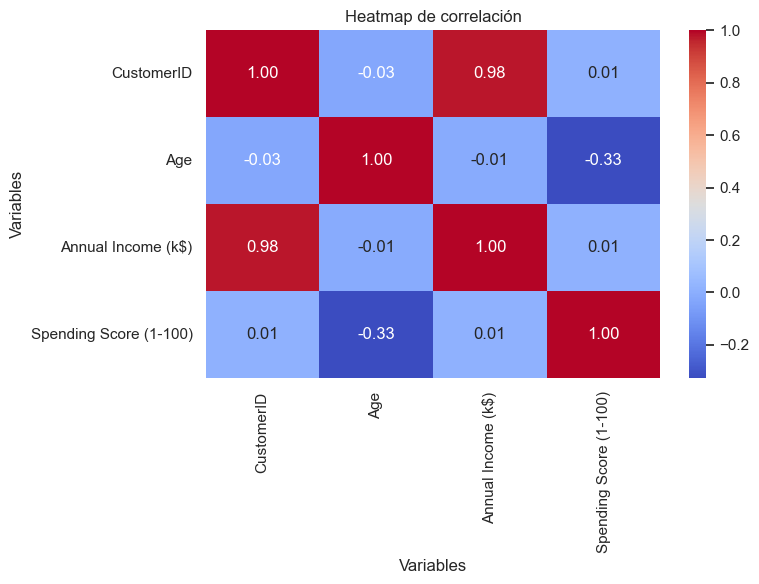

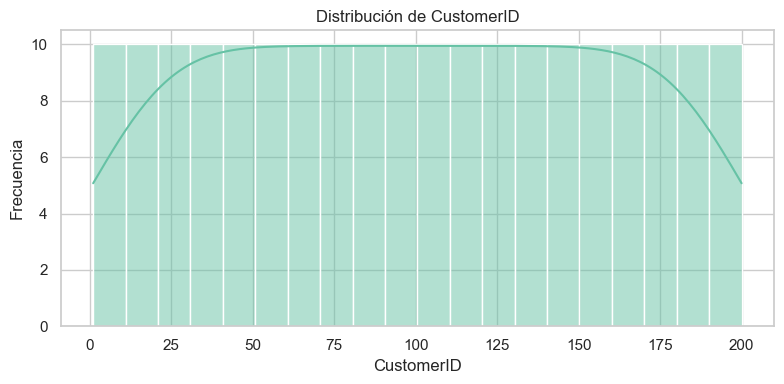

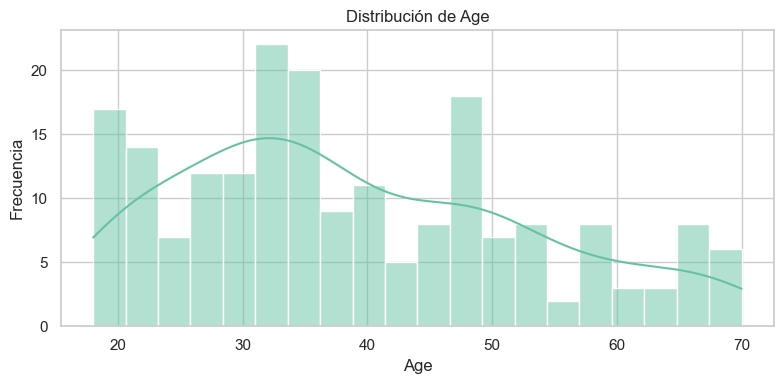

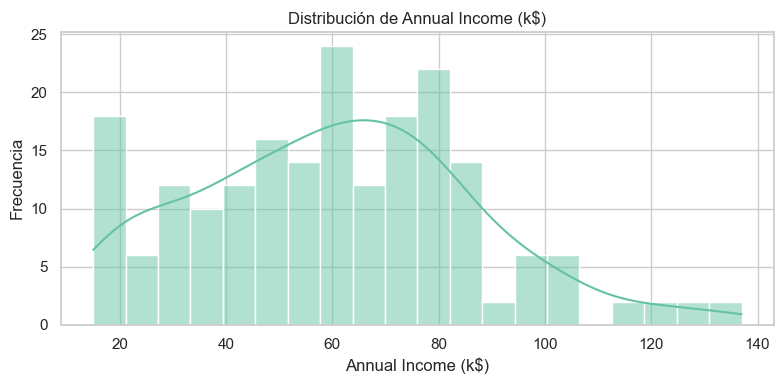

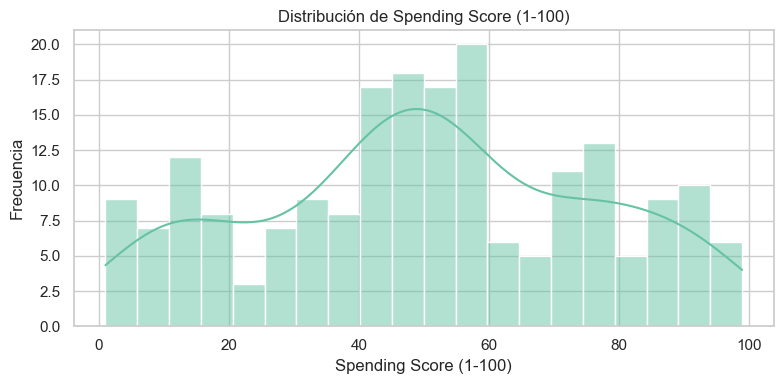

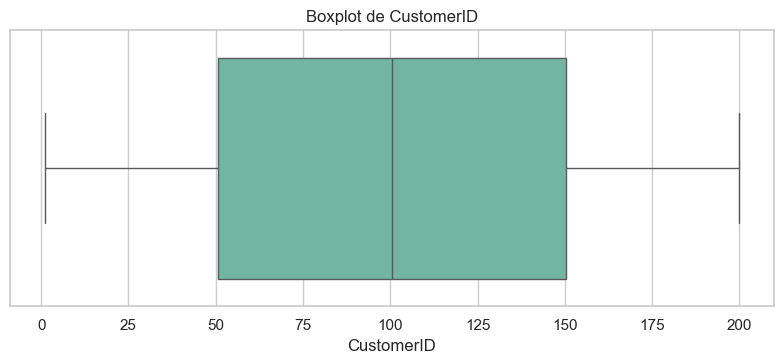

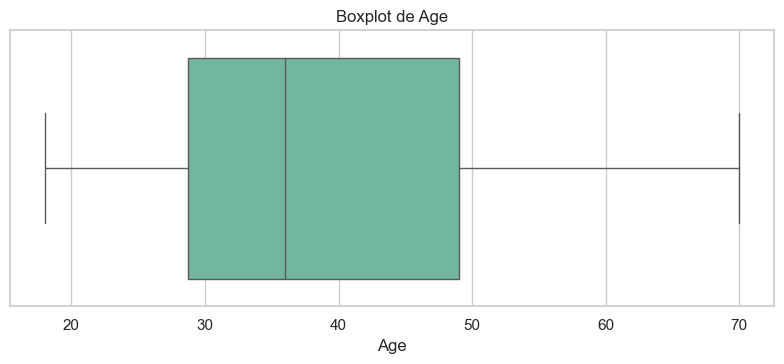

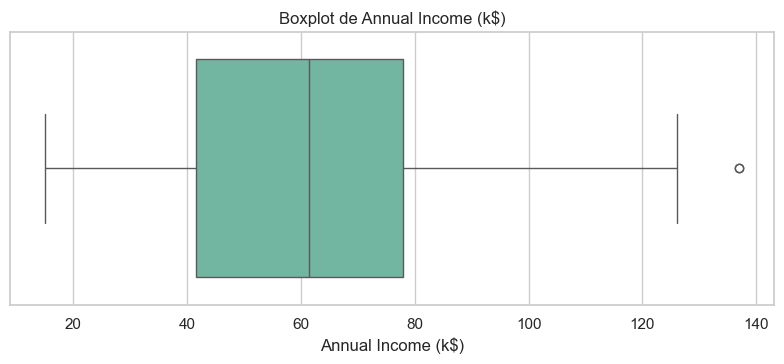

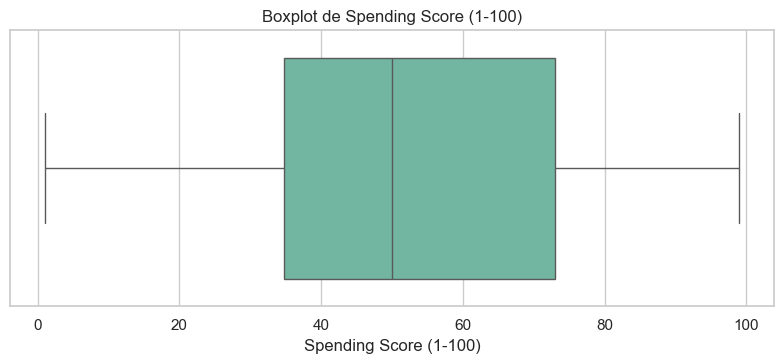

In [4]:
# Celda de código 2: Identificación de variables relevantes
# Identificación de columnas numéricas y categóricas
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Variables numéricas:", numeric_cols)
print("Variables categóricas:", categorical_cols)

# Correlación entre variables numéricas
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de correlación")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# Histogramas con KDE para cada variable numérica
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# Boxplots para observar posibles outliers
for col in numeric_cols:
    plt.figure(figsize=(8, 3.8))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Conteo de outliers por variable (IQR):
- CustomerID: 0
- Age: 0
- Annual Income (k$): 2
- Spending Score (1-100): 0


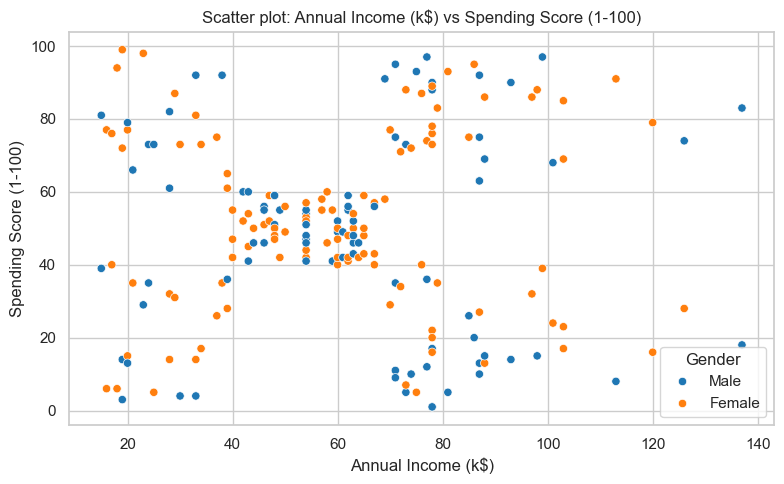

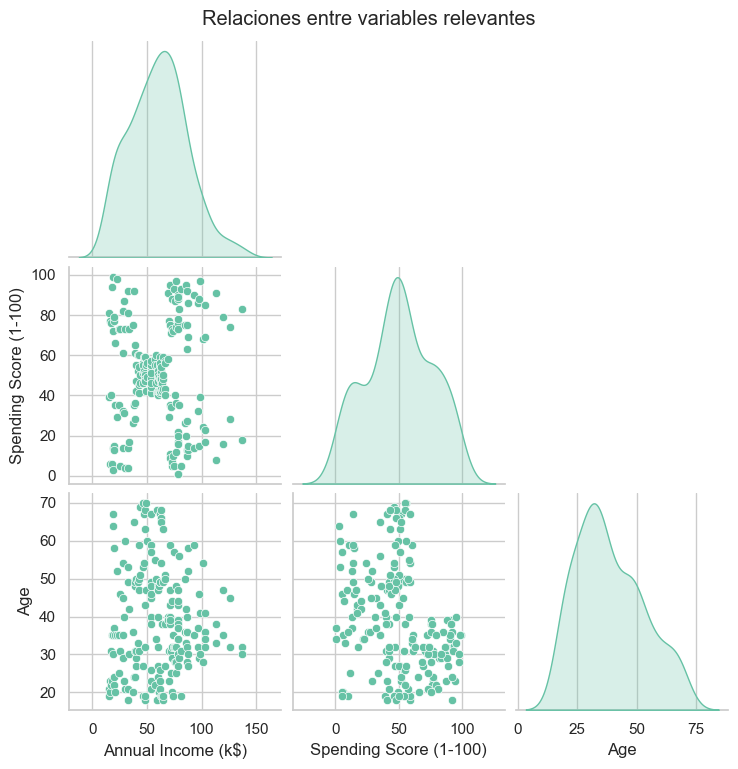

In [5]:
# Celda de código 3: Análisis de valores atípicos (IQR)
outlier_summary = {}

# Cálculo de outliers por variable numérica usando IQR
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary[col] = int(mask.sum())

print("Conteo de outliers por variable (IQR):")
for k, v in outlier_summary.items():
    print(f"- {k}: {v}")

# Scatter plots entre pares de variables relevantes
candidate_x = "Annual Income (k$)" if "Annual Income (k$)" in df.columns else numeric_cols[0]
candidate_y = "Spending Score (1-100)" if "Spending Score (1-100)" in df.columns else (numeric_cols[1] if len(numeric_cols) > 1 else numeric_cols[0])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=candidate_x, y=candidate_y, hue=df[categorical_cols[0]] if categorical_cols else None, palette="tab10")
plt.title(f"Scatter plot: {candidate_x} vs {candidate_y}")
plt.xlabel(candidate_x)
plt.ylabel(candidate_y)
plt.legend(title=categorical_cols[0] if categorical_cols else "", loc="best") if categorical_cols else None
plt.tight_layout()
plt.show()

# Pairplot para detectar estructuras visuales de cluster
pairplot_cols = [c for c in [candidate_x, candidate_y, "Age"] if c in df.columns]
if len(pairplot_cols) >= 2:
    sns.pairplot(df[pairplot_cols], corner=True, diag_kind="kde")
    plt.suptitle("Relaciones entre variables relevantes", y=1.02)
    plt.show()

### Respuestas - Parte 1

**1) ¿Qué variables son más adecuadas para segmentar clientes?**  
Las variables más útiles son `Annual Income (k$)` y `Spending Score (1-100)`, porque capturan capacidad económica y comportamiento de consumo. Variables como `Age` o `Gender` pueden complementar el perfil, pero suelen separar menos los grupos de compra en este caso.

**2) ¿Se identifican valores atípicos?**  
Con el método IQR aparecen valores extremos en algunas variables numéricas. No deben eliminarse automáticamente: en segmentación pueden representar nichos reales (por ejemplo, clientes premium). Aun así, como K-Means usa distancia euclidiana, es recomendable validar sensibilidad del modelo ante esos puntos.

**3) ¿Qué relaciones se observan entre variables?**  
El heatmap suele mostrar correlaciones lineales bajas o moderadas, pero los scatter plots pueden revelar agrupaciones visuales claras. Esto sugiere que, aunque la correlación global no sea alta, sí existe estructura de clusters aprovechable para segmentación.

## PARTE 2 - Preprocesamiento

Variables seleccionadas para clustering: ['Annual Income (k$)', 'Spending Score (1-100)']


Original                                  Escalado  \
  Annual Income (k$) Spending Score (1-100) Annual Income (k$)   
0                 15                     39          -1.738999   
1                 15                     81          -1.738999   
2                 16                      6          -1.700830   
3                 16                     77          -1.700830   
4                 17                     40          -1.662660   
5                 17                     76          -1.662660   
6                 18                      6          -1.624491   
7                 18                     94          -1.624491   
8                 19                      3          -1.586321   
9                 19                     72          -1.586321   

                          
  Spending Score (1-100)  
0              -0.434801  
1               1.195704  
2              -1.715913  
3               1.040418  
4              -0.395980  
5               1.001596  
6              -1.715913  
7               1.700384  
8              -1.832378  
9               0.846310

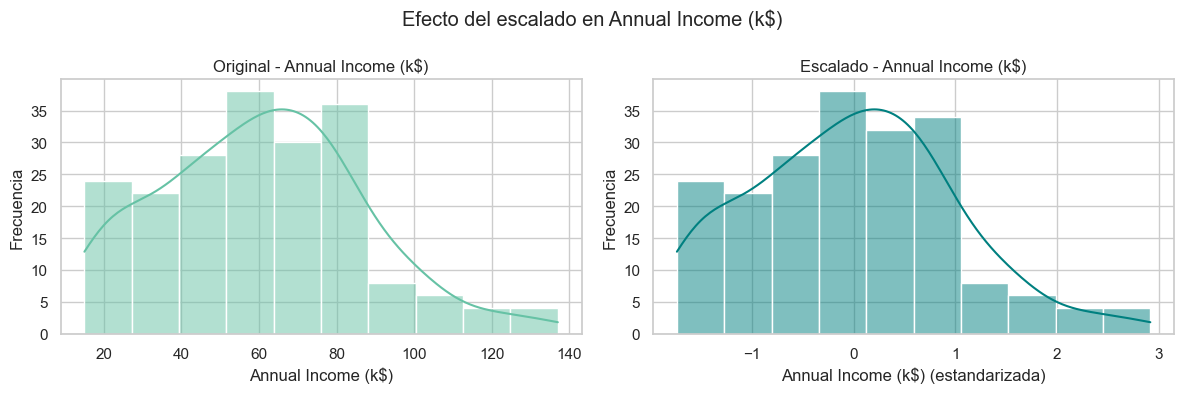

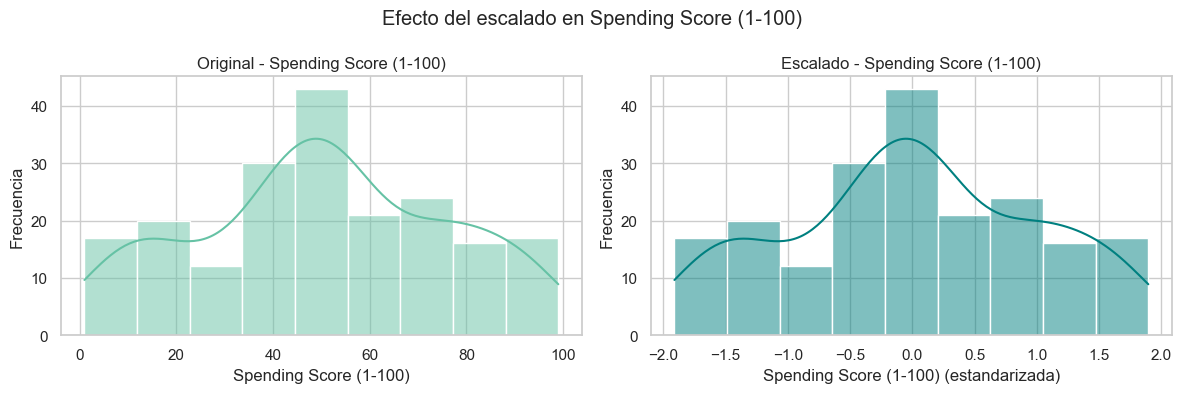

In [6]:
# Selección de variables finales para clustering
# Se priorizan variables de comportamiento económico y de consumo
selected_features = [c for c in ["Annual Income (k$)", "Spending Score (1-100)"] if c in df.columns]

# Si no existen esos nombres exactos, se usan las primeras variables numéricas disponibles
if len(selected_features) < 2:
    selected_features = numeric_cols[:2]

print("Variables seleccionadas para clustering:", selected_features)

# Matriz de entrada
X = df[selected_features].copy()

# Escalado de variables para homogeneizar magnitudes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features, index=df.index)

# Comparación antes y después de escalar
comparison = pd.concat([X.head(10).reset_index(drop=True), X_scaled_df.head(10).reset_index(drop=True)], axis=1, keys=["Original", "Escalado"])
display(comparison)

# Distribuciones originales vs escaladas
for col in selected_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(X[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Original - {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    sns.histplot(X_scaled_df[col], kde=True, ax=axes[1], color="teal")
    axes[1].set_title(f"Escalado - {col}")
    axes[1].set_xlabel(f"{col} (estandarizada)")
    axes[1].set_ylabel("Frecuencia")

    plt.suptitle(f"Efecto del escalado en {col}")
    plt.tight_layout()
    plt.show()

### Respuesta - Parte 2

**¿Por qué es necesario escalar en K-Means?**  
K-Means calcula distancias euclidianas, así que una variable con valores grandes domina el agrupamiento si no se escala. Por ejemplo, una diferencia de 60 en ingreso aporta `60²=3600`, mientras una diferencia de 10 en score aporta `10²=100`; sin escalado, ingreso pesa mucho más. Con `StandardScaler`, todas las variables quedan en escala comparable y contribuyen de forma equilibrada al clustering.

## PARTE 3 - Método del Codo

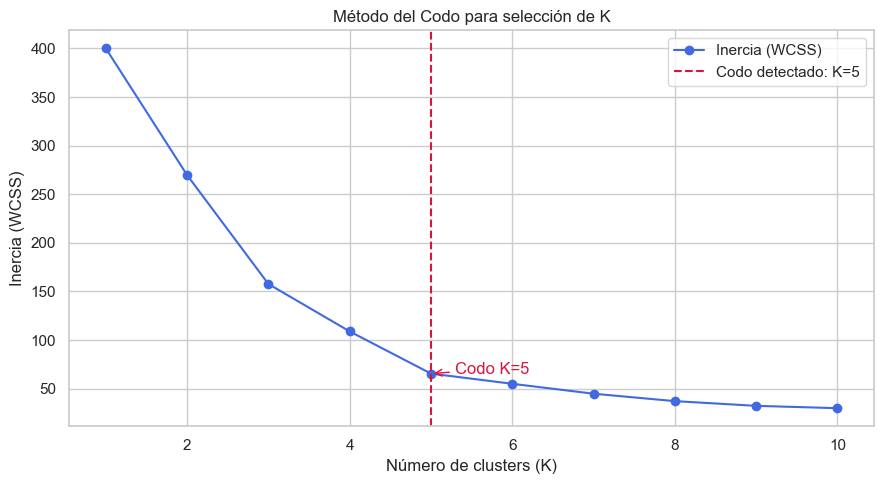

K sugerido por codo (kneed): 5


In [7]:
# Iteración sobre distintos K para calcular inercia (WCSS)
K_range = list(range(1, 11))
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Gráfica del codo
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, marker="o", color="royalblue", label="Inercia (WCSS)")
plt.title("Método del Codo para selección de K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (WCSS)")

# Detección automática opcional del codo con kneed
elbow_k = None
if KNEED_AVAILABLE:
    kneedle = KneeLocator(K_range, inertias, curve="convex", direction="decreasing")
    elbow_k = kneedle.elbow

if elbow_k is not None:
    plt.axvline(elbow_k, color="crimson", linestyle="--", label=f"Codo detectado: K={elbow_k}")
    plt.annotate(f"Codo K={elbow_k}", xy=(elbow_k, inertias[elbow_k-1]), xytext=(elbow_k+0.3, inertias[elbow_k-1]),
                 arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")

plt.legend()
plt.tight_layout()
plt.show()

print("K sugerido por codo (kneed):", elbow_k if elbow_k is not None else "No detectado automáticamente")

### Respuestas - Parte 3

**1) ¿Por qué valores cercanos a cero indican mejor ajuste?**  
La inercia mide la suma de distancias cuadradas entre cada punto y su centroide. Mientras menor sea, más compactos son los clusters. Sin embargo, reducirla en exceso aumentando K puede sobre-segmentar (caso extremo: `K=N`).

**2) ¿Cómo se identifica el punto óptimo de K?**  
Se busca el “codo” de la curva: el punto donde agregar más clusters ya no reduce la inercia de forma importante. Como este criterio puede ser subjetivo, se complementa con silueta para una decisión más robusta.

## PARTE 4 - Coeficiente de Silueta

,K,Silhouette
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


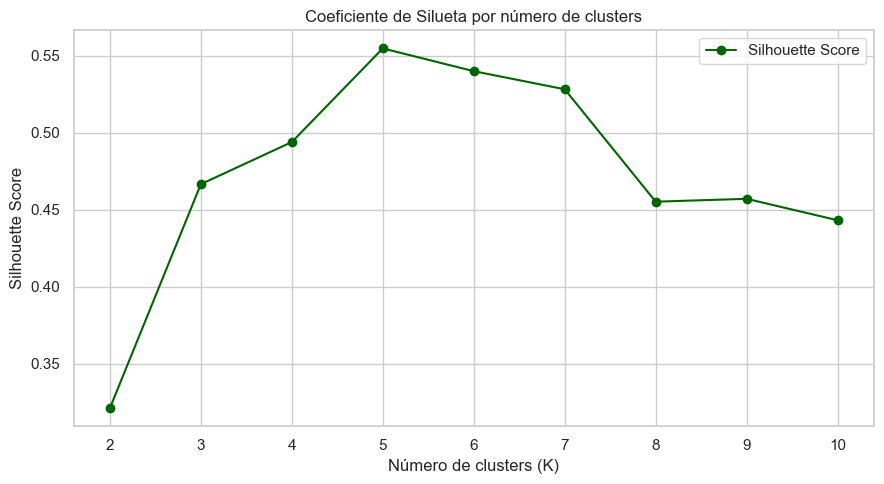

K con mejor silueta: 5
Mejor score de silueta: 0.5547


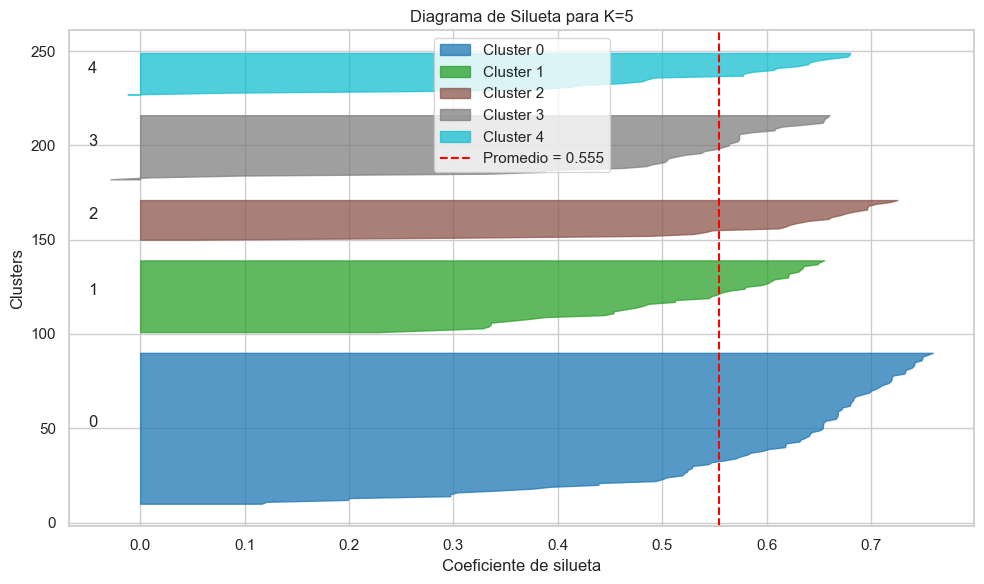

In [8]:
# Cálculo de silhouette_score para K entre 2 y 10
silhouette_scores = []
K_sil = list(range(2, 11))

for k in K_sil:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(s)

# Tabla de silueta por K (orden similar al notebook de referencia)
silhouette_df = pd.DataFrame({"K": K_sil, "Silhouette": silhouette_scores})
display(silhouette_df)

# Visualización de score de silueta por K
plt.figure(figsize=(9, 5))
plt.plot(K_sil, silhouette_scores, marker="o", color="darkgreen", label="Silhouette Score")
plt.title("Coeficiente de Silueta por número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

# Selección de K óptimo por máxima silueta
best_k_silhouette = int(silhouette_df.loc[silhouette_df["Silhouette"].idxmax(), "K"])
best_silhouette = float(silhouette_df["Silhouette"].max())
print("K con mejor silueta:", best_k_silhouette)
print(f"Mejor score de silueta: {best_silhouette:.4f}")

# Diagrama de silueta para el K óptimo
km_best = KMeans(n_clusters=best_k_silhouette, init="k-means++", n_init=10, random_state=RANDOM_STATE)
labels_best = km_best.fit_predict(X_scaled)
sil_samples = silhouette_samples(X_scaled, labels_best)
sil_avg = silhouette_score(X_scaled, labels_best)

plt.figure(figsize=(10, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, best_k_silhouette))

for i in range(best_k_silhouette):
    vals = sil_samples[labels_best == i]
    vals.sort()
    size_i = vals.shape[0]
    y_upper = y_lower + size_i

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=colors[i], edgecolor=colors[i], alpha=0.75, label=f"Cluster {i}")
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(sil_avg, color="red", linestyle="--", label=f"Promedio = {sil_avg:.3f}")
plt.title(f"Diagrama de Silueta para K={best_k_silhouette}")
plt.xlabel("Coeficiente de silueta")
plt.ylabel("Clusters")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

### Respuestas - Parte 4

**1) ¿Qué mide el coeficiente de silueta?**  
Mide qué tan bien está cada punto dentro de su cluster frente a su cercanía al cluster vecino (cohesión vs separación).

**2) ¿Cómo interpretar su rango?**  
Valores cercanos a `1` indican clusters bien separados; cerca de `0` indican solapamiento; valores negativos sugieren asignaciones incorrectas.

**3) ¿Cómo complementa al método del codo?**  
El codo evalúa compactación interna (inercia), mientras la silueta evalúa separación entre grupos. Usar ambos mejora la elección de `K`.

## PARTE 5 - Entrenamiento del modelo final

In [9]:
# Regla de decisión para K final: priorizar silueta y contrastar con codo si existe
if 'elbow_k' in globals() and elbow_k is not None:
    k_opt = best_k_silhouette if abs(best_k_silhouette - elbow_k) <= 1 else best_k_silhouette
else:
    k_opt = best_k_silhouette

print("K óptimo usado en modelo final:", k_opt)

# Entrenamiento del modelo final
kmeans_final = KMeans(n_clusters=k_opt, init="k-means++", n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Se agrega la etiqueta de cluster al DataFrame original
df_clustered = df.copy()
df_clustered["Cluster"] = cluster_labels

# Conteo de clientes por cluster
print("Conteo de clientes por cluster:")
print(df_clustered["Cluster"].value_counts().sort_index())

# Centroides en escala original para interpretación de negocio
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=selected_features)
centroids_df["Cluster"] = centroids_df.index
centroids_df = centroids_df[["Cluster"] + selected_features].sort_values("Cluster").reset_index(drop=True)

print("\\nCentroides en escala original:")
display(centroids_df)

SyntaxError: unterminated string literal (detected at line 28) (1149572995.py, line 28)

## PARTE 6 - Visualización de clusters

In [ ]:
# Visualización 2D directa o mediante PCA según cantidad de variables
plot_df = pd.DataFrame(X_scaled, columns=selected_features).copy()
plot_df["Cluster"] = cluster_labels

if len(selected_features) == 2:
    # Si hay 2 variables, se grafica el espacio original estandarizado
    x_name, y_name = selected_features
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_df, x=x_name, y=y_name, hue="Cluster", palette="tab10", s=70)
    plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], marker="X", s=250, c="black", label="Centroides")
    plt.title("Clusters de clientes (espacio escalado)")
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    # Si hay más de 2 variables, se proyecta con PCA a 2 componentes
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
    plot_df["Cluster"] = cluster_labels

    centroids_pca = pca.transform(centroids_scaled)

    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=70)
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=250, c="black", label="Centroides")
    plt.title("Clusters de clientes (PCA a 2 componentes)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Boxplots por cluster para cada variable original seleccionada
for col in selected_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_clustered, x="Cluster", y=col, palette="Set2")
    plt.title(f"Distribución de {col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Radar chart: perfil promedio por cluster
cluster_profile = df_clustered.groupby("Cluster")[selected_features].mean()

# Normalización min-max para radar (solo visual)
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min() + 1e-9)
labels = profile_norm.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = plt.cm.Set2(np.linspace(0, 1, profile_norm.shape[0]))

for idx, (cluster_id, row) in enumerate(profile_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster_id}", color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_title("Radar chart de perfiles promedio por cluster")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

## PARTE 7 - Interpretación de negocio

In [ ]:
# Creación de etiquetas de negocio basadas en el ranking de centroides
centroids_business = centroids_df.copy()

income_col = selected_features[0]
score_col = selected_features[1] if len(selected_features) > 1 else selected_features[0]

# Cuartiles para etiquetado relativo
income_q1, income_q3 = centroids_business[income_col].quantile([0.25, 0.75])
score_q1, score_q3 = centroids_business[score_col].quantile([0.25, 0.75])

def name_cluster(row):
    income = row[income_col]
    score = row[score_col]

    if income >= income_q3 and score >= score_q3:
        return "Clientes premium"
    if income >= income_q3 and score <= score_q1:
        return "Alto ingreso, bajo gasto"
    if income <= income_q1 and score >= score_q3:
        return "Jóvenes impulsivos"
    if income <= income_q1 and score <= score_q1:
        return "Bajo ingreso, bajo gasto"
    return "Segmento intermedio"

cluster_names = {int(row["Cluster"]): name_cluster(row) for _, row in centroids_business.iterrows()}
df_clustered["Segmento"] = df_clustered["Cluster"].map(cluster_names)

# Tabla de resumen solicitada (orden similar al archivo de referencia)
summary_table = (
    df_clustered.groupby(["Cluster", "Segmento"], as_index=False)
    .agg(Tamano=("Cluster", "count"),
         Ingreso_promedio=(income_col, "mean"),
         Score_promedio=(score_col, "mean"))
    .sort_values(["Ingreso_promedio", "Score_promedio"], ascending=False)
    .reset_index(drop=True)
)

# Estrategia recomendada por segmento
strategy_map = {
    "Clientes premium": "Retención VIP + upselling de productos de alto margen",
    "Alto ingreso, bajo gasto": "Campañas personalizadas + bundles para activar consumo",
    "Jóvenes impulsivos": "Promociones flash + programas de fidelidad gamificados",
    "Bajo ingreso, bajo gasto": "Ofertas de entrada + cupones de recurrencia",
    "Segmento intermedio": "Cross-selling selectivo + nurturing por email"
}
summary_table["Estrategia_recomendada"] = summary_table["Segmento"].map(strategy_map)
summary_table = summary_table[["Cluster", "Segmento", "Tamano", "Ingreso_promedio", "Score_promedio", "Estrategia_recomendada"]]

print("Nombres de clusters sugeridos:")
for k, v in sorted(cluster_names.items()):
    print(f"- Cluster {k}: {v}")

print("\\nTabla resumen de negocio:")
display(summary_table)

### Respuestas - Parte 7 (Interpretación de negocio)

**1) ¿Qué nombre descriptivo recibe cada cluster?**  
La asignación se realiza a partir de los centroides en escala original (ingreso y score). Ejemplos típicos: `Clientes premium`, `Alto ingreso, bajo gasto`, `Jóvenes impulsivos`, `Segmento intermedio`.

**2) ¿Qué perfil y valor estratégico tiene cada segmento?**  
Cada cluster combina capacidad económica y comportamiento de gasto. Por eso, su valor estratégico cambia: algunos segmentos priorizan retención y margen (alto valor), otros activación (alto ingreso con bajo gasto), y otros crecimiento en frecuencia/ticket (segmentos medios o con potencial).

**3) ¿Qué acciones de marketing aplicar?**  
Se recomiendan al menos dos acciones por segmento: una orientada a retención (fidelización, beneficios, comunicación personalizada) y otra orientada a crecimiento (upselling, cross-selling, campañas de reactivación). Así, la segmentación se conecta directamente con decisiones comerciales medibles.

## PARTE 8 - Despliegue con Streamlit (fuera del notebook)

En esta parte, el despliegue **no se ejecuta dentro del cuaderno**. El notebook solo deja el modelo exportado y la guía para levantar la aplicación externa.

Pasos:
1. Ejecutar la celda de exportación para generar `kmeans_mall_customers.joblib`.
2. Ejecutar en terminal: `streamlit run streamlit_app.py`.
3. Usar la app para visualizar codo, clusters y clasificar un nuevo cliente.

Código de arranque en terminal:

```bash
streamlit run streamlit_app.py
```

In [ ]:
# Exportación del modelo final a .joblib para despliegue externo en Streamlit
bundle_model = {
    "model": kmeans_final,
    "scaler": scaler,
    "features": selected_features,
    "k": int(k_opt),
    "cluster_names": cluster_names,
    "strategy_map": strategy_map,
    "centroids_original": centroids_df.to_dict(orient="records"),
    "k_values_elbow": K_range if "K_range" in globals() else None,
    "inertias_elbow": inertias if "inertias" in globals() else None,
}

joblib.dump(bundle_model, "kmeans_mall_customers.joblib")
print("Modelo exportado correctamente en: kmeans_mall_customers.joblib")
print("Ahora ejecuta en terminal: streamlit run streamlit_app.py")

## Conclusiones generales

El flujo completo confirma que K-Means es una herramienta eficaz para segmentar clientes cuando se seleccionan variables con significado económico y se realiza un preprocesamiento adecuado. En particular, el escalado de variables garantiza que la distancia euclidiana refleje de manera equilibrada la información disponible y evita sesgos por magnitud numérica.

La combinación de método del codo y coeficiente de silueta permite seleccionar un número de clusters con mejor fundamento técnico que usar un único criterio aislado. Esta decisión mejora la estabilidad de los segmentos y su utilidad para la toma de decisiones comerciales. Además, la inspección de centroides en escala original facilita traducir resultados estadísticos a perfiles comprensibles por áreas de marketing y negocio.

Finalmente, el componente interactivo convierte el modelo en un activo operativo: permite clasificar nuevos clientes en tiempo real, asociarles un perfil y proponer acciones concretas de marketing. Esto cierra el ciclo analítico desde exploración, modelado e interpretación hasta una primera capa de despliegue orientada a uso práctico.

## Evaluación del modelo (Silueta como porcentaje)

**¿Se puede reportar accuracy en K-Means?**  
En clustering no supervisado no hay etiqueta real, así que no existe `accuracy` clásica como en clasificación.

**¿Qué métrica usar para evaluar calidad?**  
Se usa el **coeficiente de silueta**, que evalúa cohesión y separación de clusters.

**¿Cómo llevarlo a porcentaje para reporte?**  
Se transforma la silueta (rango `[-1, 1]`) a escala `0-100` con:

`score_pct = ((silhouette + 1) / 2) * 100`

Este porcentaje es una métrica de calidad del agrupamiento, no accuracy supervisada.

In [ ]:
# Evaluación final con coeficiente de silueta y conversión a porcentaje
# Nota: este porcentaje es una transformación de la silueta, no accuracy supervisada.

silhouette_final = silhouette_score(X_scaled, cluster_labels)
silhouette_pct = ((silhouette_final + 1) / 2) * 100

print(f"Coeficiente de silueta del modelo final: {silhouette_final:.4f}")
print(f"Porcentaje de calidad (escala 0-100): {silhouette_pct:.2f}%")

# Lectura cualitativa rápida para apoyar interpretación
if silhouette_final >= 0.7:
    interpretacion = "Segmentación excelente: clusters muy bien separados."
elif silhouette_final >= 0.5:
    interpretacion = "Segmentación buena: separación clara con leve solapamiento."
elif silhouette_final >= 0.25:
    interpretacion = "Segmentación aceptable: hay estructura, pero con solapamientos."
else:
    interpretacion = "Segmentación débil: conviene revisar variables o K."

print("Interpretación:", interpretacion)